In [333]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from hdbscan import HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE

RANDOM_STATE: int = 568

# Preprocessing

In [334]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess the dataset by dropping unnecessary columns and handling missing values.

    Args:
        df (pd.DataFrame): The input DataFrame to preprocess.

    Returns:
        pd.DataFrame: The preprocessed DataFrame.
    """
    df.drop(columns=['Sequence_ID'], inplace=True)
    feature_names: pd.Index[str] = df.columns[:-1]

    df = df[df[feature_names].sum(axis=1) > 0]

    df["Virus_Species"] = df["Virus_Species"].apply(lambda x: x.lower())
    
    valid_classes: set[str] = {
        "orthohantavirus puumalaense", 
        "orthohantavirus dobravaense", 
        "orthohantavirus hantanense",
        "orthohantavirus sinnombreense"
    }
    df.drop(df[~df["Virus_Species"].isin(valid_classes)].index, axis=0, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df

In [335]:
def drop_low_correlation_features(df: pd.DataFrame, feature_names: list[str], threshold=0.9) -> tuple[pd.DataFrame, list[str]]:
    """
    Identifies highly correlated features and drops one of each pair to remove redundancy.

    Args:
        df (pd.DataFrame): The input DataFrame.
        feature_names (list[str]): The original list of feature column names.
        threshold (float): The correlation coefficient threshold above which a feature is dropped.

    Returns:
        tuple[pd.DataFrame, list[str]]: The DataFrame with dropped features and the updated list of feature names.
    """
    print(f"Original number of features: {len(feature_names)}")
    
    corr_matrix: pd.DataFrame = df[feature_names].corr().abs()
    upper_tri: pd.DataFrame = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop: list[str] = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    
    df_filtered: pd.DataFrame = df.drop(columns=to_drop)
    updated_feature_names: list[str] = [f for f in feature_names if f not in to_drop]
    
    print(f"Updated number of features: {len(updated_feature_names)}\n")
    return df_filtered, updated_feature_names

In [336]:
from sklearn.model_selection import train_test_split

def split_and_scale_data(
    df: pd.DataFrame, 
    feature_names: list[str]
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """
    Splits data into train, validation, and test sets, and scales the features.

    Args:
        df (pd.DataFrame): The input preprocessed DataFrame.
        feature_names (list[str]): List of columns to use as features.

    Returns:
        tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]: 
        Scaled DataFrames (train, val, test) and their corresponding ground truth labels.
    """
    X: pd.DataFrame = df[feature_names]
    y: pd.Series = df["Virus_Species"]
    
    # Stratified split based on species to keep historical context/alignment
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=RANDOM_STATE, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1, random_state=RANDOM_STATE, stratify=y_temp)
    
    scaler: StandardScaler = StandardScaler()
    X_train_scaled: pd.DataFrame = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
    X_val_scaled: pd.DataFrame = pd.DataFrame(scaler.transform(X_val), columns=feature_names)
    X_test_scaled: pd.DataFrame = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

    print("Dataset split results:")
    print(f"\tTrain set shape:      X_train: {X_train_scaled.shape}, y_train: {y_train.shape}")
    print(f"\tValidation set shape: X_val: {X_val_scaled.shape}, y_val: {y_val.shape}")
    print(f"\tTest set shape:       X_test: {X_test_scaled.shape}, y_test: {y_test.shape}\n")

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test

In [337]:
from sklearn.decomposition import PCA

def apply_pca(
    X_train: pd.DataFrame, 
    X_val: pd.DataFrame, 
    X_test: pd.DataFrame, 
    n_components: int | float = 0.9
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Applies Principal Component Analysis (PCA) to reduce the dimensionality of the datasets.

    Args:
        X_train (pd.DataFrame): Scaled training features.
        X_val (pd.DataFrame): Scaled validation features.
        X_test (pd.DataFrame): Scaled test features.
        n_components (int | float): Number of components to keep. If float between 0 and 1, 
                                     it represents the variance ratio to preserve.

    Returns:
        tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]: Reduced train, validation, and test DataFrames.
    """
    print(f"Applying PCA (target variance/components: {n_components})...")
    print(f"Shape before PCA: {X_train.shape}")
    
    pca: PCA = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_train_pca: np.ndarray = pca.fit_transform(X_train)
    X_val_pca: np.ndarray = pca.transform(X_val)
    X_test_pca: np.ndarray = pca.transform(X_test)
    
    pca_cols: list[str] = [f"PC_{i+1}" for i in range(X_train_pca.shape[1])]
    
    X_train_reduced: pd.DataFrame = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
    X_val_reduced: pd.DataFrame = pd.DataFrame(X_val_pca, columns=pca_cols, index=X_val.index)
    X_test_reduced: pd.DataFrame = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)
    
    print(f"Shape after PCA: {X_train_reduced.shape}")
    print(f"Total explained variance ratio: {sum(pca.explained_variance_ratio_):.4f}\n")
    
    return X_train_reduced, X_val_reduced, X_test_reduced

# Training the models

In [338]:
MODEL_NAMES: list[str] = [
    "K-Means (Baseline)",
    "DBSCAN",
    "HDBSCAN",
    "Agglomerative Clustering",
    "Spectral Clustering",
    "Gaussian Mixture Models"
]

N_CLUSTERS: int = 4  # Aligned with the 4 biological virus species

optimal_models: dict[str, object] = {}
silhouette_results: dict[str, float] = {}
val_predictions: dict[str, np.ndarray] = {}
test_predictions: dict[str, np.ndarray] = {}

def create_clustering_model(model_name: str, params: dict) -> object:
    """
    Instantiates a clustering algorithm configuration based on the provided model name.

    Args:
        model_name (str): The name of the clustering algorithm.
        params (dict): Hyperparameters for the model.

    Returns:
        object: An instance of the requested clustering model.
    """
    if model_name == "K-Means (Baseline)":
        return KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, **params)
    elif model_name == "DBSCAN":
        return DBSCAN(**params)
    elif model_name == "HDBSCAN":
        return HDBSCAN(**params)
    elif model_name == "Agglomerative Clustering":
        return AgglomerativeClustering(n_clusters=N_CLUSTERS, **params)
    elif model_name == "Spectral Clustering":
        return SpectralClustering(
            n_clusters=N_CLUSTERS, 
            random_state=RANDOM_STATE, 
            eigen_solver="lobpcg",
            assign_labels="discretize",
            n_jobs=-1,
            **params
        )
    elif model_name == "Gaussian Mixture Models":
        return GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE, **params)
    return None

In [339]:
def calculate_density_score_helper(
    X: pd.DataFrame, 
    labels: np.ndarray, 
    non_noise_mask: np.ndarray,
    metric: str = "silhouette"
) -> float:
    """
    Helper function to calculate the density-based clustering score based on the specified metric.
    
    Args:
        X (pd.DataFrame): The input DataFrame containing the features.
        labels (np.ndarray): The predicted cluster labels for the samples.
        non_noise_mask (np.ndarray): A boolean mask indicating which samples are not noise (i.e., not labeled as -1).
        metric (str): The metric to compute. Defaults to "silhouette".

    Returns:
        float: Calculated density-based clustering score metric validation value.
    """
    base_score: float = 0
    metric_lower: str = metric.lower()
    if metric_lower == "silhouette":
        base_score = float(silhouette_score(X[non_noise_mask], labels[non_noise_mask]))
    elif metric_lower == "davies_bouldin":
        base_score = float(davies_bouldin_score(X[non_noise_mask], labels[non_noise_mask]))
    elif metric_lower == "calinski_harabasz":
        base_score = float(calinski_harabasz_score(X[non_noise_mask], labels[non_noise_mask]))

    return base_score

In [340]:
def calculate_density_score_all_sequences(
    X: pd.DataFrame, 
    labels: np.ndarray,
    model_name: str,
    metric: str = "silhouette"
) -> float:
    """
    Computes the score specifically filtered for density-based algorithms on all sequences by isolating noise.

    Args:
        X (pd.DataFrame): Dataset partition features.
        labels (np.ndarray): Clustering label assignments containing possible noise signals.
        model_name (str): The name of the clustering model.
        metric (str): The metric to compute. Defaults to "silhouette".

    Returns:
        float: Calculated density-based clustering score metric validation value.
    """
    non_noise_mask: np.ndarray = labels != -1
    unique_labels: set[int] = set(labels[non_noise_mask])
    
    if len(unique_labels) < 2:
        return 0
        
    return calculate_density_score_helper(
        X=X, 
        labels=labels, 
        non_noise_mask=non_noise_mask, 
        metric=metric
    )

In [341]:
def calculate_density_score_complete_sequences(
    X: pd.DataFrame, 
    labels: np.ndarray,
    model_name: str,
    metric: str = "silhouette"
) -> float:
    """
    Computes the score specifically filtered for density-based algorithms on complete sequences by isolating noise.

    Args:
        X (pd.DataFrame): Dataset partition features.
        labels (np.ndarray): Clustering label assignments containing possible noise signals.
        model_name (str): The name of the clustering model.
        metric (str): The metric to compute. Defaults to "silhouette".

    Returns:
        float: Calculated density-based clustering score metric validation value.
    """
    non_noise_mask: np.ndarray = labels != -1
    unique_labels: set[int] = set(labels[non_noise_mask])
    
    if len(unique_labels) < 2:
        return 0
        
    base_score: float = calculate_density_score_helper(
        X=X, 
        labels=labels, 
        non_noise_mask=non_noise_mask, 
        metric=metric
    )
    
    total_samples: int = len(labels)
    noise_samples: int = int(np.sum(labels == -1))
    noise_ratio: float = noise_samples / total_samples

    if noise_ratio > 0.30:
        return base_score * (1.0 - noise_ratio)
        
    return base_score

In [342]:
def calculate_density_score_by_metric(
    X: pd.DataFrame, 
    labels: np.ndarray, 
    model_name: str,
    metric: str = "silhouette",
    is_all_sequences_dataset: bool = True
) -> float:
    """
    Computes the score specifically filtered for density-based algorithms by isolating noise, based on the sequence completeness.

    Args:
        X (pd.DataFrame): Dataset partition features.
        labels (np.ndarray): Clustering label assignments containing possible noise signals.
        model_name (str): The name of the clustering model.
        metric (str): The metric to compute. Defaults to "silhouette".
        is_all_sequences_dataset (bool): True if the dataset contains all sequences, False otherwise.

    Returns:
        float: Calculated density-based clustering score metric validation value.
    """
    if is_all_sequences_dataset:
        return calculate_density_score_all_sequences(
            X=X, 
            labels=labels,
            model_name=model_name,
            metric=metric
        )
    return calculate_density_score_complete_sequences(
        X=X, 
        labels=labels,
        model_name=model_name,
        metric=metric
    )

In [343]:
def model_requires_fit_predict(model_name: str) -> bool:
    """
    Determines if the clustering model requires the `fit_predict` method instead of separate `fit` and `predict` calls. 

    Args:
        model_name (str): The name of the clustering algorithm.

    Returns:
        bool: True if the model requires `fit_predict`, False otherwise.
    """
    return model_name in {"Agglomerative Clustering", "Spectral Clustering", "DBSCAN", "HDBSCAN"}

In [344]:
from typing import Any

PARAM_GRID_ALL: dict[str, dict[str, list[Any]]] = {
    "K-Means (Baseline)": {
        "init": ["k-means++", "random"], 
        "n_init": [x*10 for x in range(1, 6)]
    },  
    "DBSCAN": {
        "min_samples": [3, 5, 10, 15, 20],
        "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
        "metric": ["euclidean", "manhattan"]
    },
    "HDBSCAN": {
        "min_cluster_size": [5, 10, 15, 20, 30],
        "min_samples": [3, 5, 10, 15],
        "cluster_selection_epsilon": [0.0, 0.05, 0.1, 0.2],
        "cluster_selection_method": ["eom", "leaf"],
        "metric": ["euclidean", "manhattan"]
    },
    "Agglomerative Clustering": {
        "linkage": ["ward", "average", "complete", "single"]
    },
    "Spectral Clustering": {
        "affinity": ["nearest_neighbors", "rbf"], 
        "n_neighbors": [3, 5, 10, 15, 20, 25]
    },
    "Gaussian Mixture Models": {
        "covariance_type": ["spherical", "tied", "full"]
    }
}

PARAM_GRID_COMPLETE: dict[str, dict[str, list[Any]]] = {
    "K-Means (Baseline)": {
        "init": ["k-means++", "random"],
        "n_init": [5, 10, 15, 20]
    },  
    "DBSCAN": {
        "min_samples": [2, 3, 4, 5],
        "metric": ["euclidean", "manhattan", "cosine"]
    },
    "HDBSCAN": {
        "min_cluster_size": [4, 6, 8, 10],
        "min_samples": [1, 2, 3],
        "cluster_selection_method": ["eom", "leaf"],
        "metric": ["euclidean", "manhattan"]
    },
    "Agglomerative Clustering": {
        "linkage": ["ward", "average", "complete", "single"]
    },
    "Spectral Clustering": {
        "affinity": ["nearest_neighbors", "rbf"],
        "n_neighbors": [2, 3, 5, 7, 10, 12]
    },
    "Gaussian Mixture Models": {
        "covariance_type": ["spherical", "tied", "full"]
    }
}

In [345]:
import warnings

def train_clustering_models(
    X_train: pd.DataFrame, 
    X_val: pd.DataFrame,
    is_all_sequences_dataset: bool = True
) -> None:
    """
    Tunes and fits clustering models on training/validation partitions using Silhouette Score.

    Args:
        X_train (pd.DataFrame): Scaled training features.
        X_val (pd.DataFrame): Scaled validation features.
        is_all_sequences_dataset (bool): True if the dataset contains all sequences, False otherwise.

    Returns:
        None
    """
    warnings.filterwarnings("ignore", message="Graph is not fully connected")
    warnings.filterwarnings("ignore", message="Exited at iteration")
    warnings.filterwarnings("ignore", message="Exited postprocessing")

    param_grid: dict[str, dict[str, list[Any]]] = PARAM_GRID_ALL if is_all_sequences_dataset else PARAM_GRID_COMPLETE

    for model_name in MODEL_NAMES:
        best_score: float = -1.0
        best_params: dict[str, Any] = {}

        grid: dict[str, list[Any]] = param_grid[model_name]
        keys, values = zip(*grid.items())
        experiments: list[dict[str, Any]] = [dict(zip(keys, v)) for v in itertools.product(*values)]

        for params in experiments:
            # If the linkage is 'ward', the metric must be 'euclidean' for Agglomerative Clustering
            if (
                model_name == "Agglomerative Clustering" 
                and params.get("linkage") == "ward" 
                and params.get("metric", "euclidean") != "euclidean"
            ):
                continue

            model: object = create_clustering_model(model_name, params)
            if model_requires_fit_predict(model_name):
                labels_val: np.ndarray = model.fit_predict(X_val)
            else:
                model.fit(X_train)
                labels_val = model.predict(X_val)

            if model_name in ["DBSCAN", "HDBSCAN"]:
                score: float = calculate_density_score_by_metric(
                    X=X_val, 
                    labels=labels_val, 
                    model_name=model_name,
                    metric="silhouette",
                    is_all_sequences_dataset=is_all_sequences_dataset
                )
            else:
                unique_labels = set(labels_val)
                if len(unique_labels) < 2:
                    continue
                score = float(silhouette_score(X_val, labels_val))

            if score > best_score:
                best_score = score
                best_params = params

        print(f"Optimal {model_name} framework setup:")
        for param_name, param_value in best_params.items():
            print(f"    {param_name}: {param_value}")
        print(f"Validation Silhouette Score: {best_score:.4f}\n\n")

        final_model: object = create_clustering_model(model_name, best_params)
        if model_requires_fit_predict(model_name):
            val_predictions[model_name] = final_model.fit_predict(X_val)
        else:
            final_model.fit(X_train)
            val_predictions[model_name] = final_model.predict(X_val)

        optimal_models[model_name] = final_model

In [346]:
def evaluate_clustering_performance(X_test: pd.DataFrame) -> None:
    """
    Computes external/internal mathematical assessment metrics on the finalized unseen test set.

    Args:
        X_test (pd.DataFrame): Scaled test dataset features.

    Returns:
        None
    """
    print("\nFinal Evaluation Metrics on Test Set:")
    
    for model_name in MODEL_NAMES:
        model: object = optimal_models[model_name]
        
        if model_requires_fit_predict(model_name):
            labels_test: np.ndarray = model.fit_predict(X_test)
        else:
            labels_test = model.predict(X_test)
            
        test_predictions[model_name] = labels_test
        
        if model_name in ["DBSCAN", "HDBSCAN"]:
            sil: float = calculate_density_score_by_metric(
                X=X_test, 
                labels=labels_test, 
                model_name=model_name,
                metric="silhouette",
                is_all_sequences_dataset=True
            )
            db: float = calculate_density_score_by_metric(
                X=X_test, 
                labels=labels_test, 
                model_name=model_name,
                metric="davies_bouldin",
                is_all_sequences_dataset=True
            )
            ch: float = calculate_density_score_by_metric(
                X=X_test, 
                labels=labels_test, 
                model_name=model_name,
                metric="calinski_harabasz",
                is_all_sequences_dataset=True
            )
        else:
            sil = float( silhouette_score(X_test, labels_test) )
            db = davies_bouldin_score(X_test, labels_test)
            ch = calinski_harabasz_score(X_test, labels_test)
        
        silhouette_results[model_name] = sil
        
        print(f"\n--- {model_name} ---")
        print(f"Silhouette Score: {sil:.4f}")
        print(f"Davies-Bouldin Index: {db:.4f}")
        print(f"Calinski-Harabasz Score: {ch:.4f}")

In [347]:
def plot_silhouette_results(results: dict) -> None:
    """
    Plots a sorted bar chart comparison of Silhouette coefficients across models.

    Args:
        results (dict): Dictionary with model names as keys and Silhouette scores as values.

    Returns:
        None
    """
    sorted_results: list[tuple[str, float]] = sorted(results.items(), key=lambda item: item[1], reverse=True)
    names, values = zip(*sorted_results)

    plt.figure(figsize=(12, 5))
    sns.barplot(
        x=list(names), 
        y=list(values), 
        palette="YlGnBu", 
        hue=list(names), 
        legend=False
    )
    
    plt.title("Test Silhouette Score for Optimized Clustering Frameworks", fontsize=14, pad=15)
    plt.ylabel("Silhouette Score (-1.0 to 1.0)", fontsize=12)
    plt.xlabel("Optimized Clusterers", fontsize=12)
    plt.axhline(0, color="red", linestyle="--", linewidth=1)

    for idx, val in enumerate(values):
        plt.text(idx, val + 0.01 if val >= 0 else val - 0.03, f"{val:.4f}", ha="center", fontweight="bold", fontsize=11)

    plt.tight_layout()
    plt.show()

In [348]:
def plot_tsne_clusters(X_test: pd.DataFrame, predictions: dict[str, np.ndarray]) -> None:
    """
    Reduces the test feature footprint via t-SNE and projects the predicted structural clusters.

    Args:
        X_test (pd.DataFrame): Scaled test dataset features.
        predictions (dict): Dictionary mapping model names to their predicted cluster arrays.

    Returns:
        None
    """
    tsne: TSNE = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_jobs=-1)
    X_embedded: np.ndarray = tsne.fit_transform(X_test)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.ravel()
    
    for idx, model_name in enumerate(MODEL_NAMES):
        ax = axes[idx]
        
        unique_labels: np.ndarray = np.unique(predictions[model_name])
        num_labels: int = len(unique_labels)
        current_cmap = plt.get_cmap("Set1", num_labels)
        
        scatter = ax.scatter(
            X_embedded[:, 0],
            X_embedded[:, 1],
            c=predictions[model_name],
            cmap=current_cmap,
            edgecolor="k",
            alpha=0.9,
            s=40,
            vmin=unique_labels.min() - 0.5,
            vmax=unique_labels.max() + 0.5
        )
        
        ax.set_title(f"{model_name} Clusters", fontsize=12, fontweight="bold")
        ax.set_xlabel("t-SNE Dimension 1")
        ax.set_ylabel("t-SNE Dimension 2")
        
        cbar = fig.colorbar(scatter, ax=ax, ticks=unique_labels)
        cbar.set_label("Cluster ID", fontweight="bold")
        cbar.ax.set_yticklabels([str(int(lbl)) for lbl in unique_labels])
        
    if len(MODEL_NAMES) < len(axes):
        for i in range(len(MODEL_NAMES), len(axes)):
            fig.delaxes(axes[i])
        
    plt.suptitle("Unsupervised Sequence Clustering Topography mapped inside 2D t-SNE Space", fontsize=15, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()

In [358]:
def train_and_evaluate(
    df: pd.DataFrame, 
    feature_names: list[str], 
    should_apply_pca: bool = False,
    is_all_sequences_dataset: bool = True
) -> None:
    """
    Orchestrates data pipeline processing, scaling, unsupervised training, structure evaluation, and spatial charts.

    Args:
        df (pd.DataFrame): Raw structural dataset input.
        feature_names (list[str]): Initial genomic sequence characteristics list.
        should_apply_pca (bool): True if the dimensionality reduction via PCA should be applied before clustering, False otherwise.
        is_all_sequences_dataset (bool): True if the dataset contains all sequences, False otherwise.

    Returns:
        None
    """
    df_cleaned: pd.DataFrame = preprocess_data(df)

    threshold: float = 0.9 if is_all_sequences_dataset else 0.75
    df_filtered, updated_features = drop_low_correlation_features(df_cleaned, feature_names, threshold=threshold)
    X_train, X_val, X_test, _, _, _ = split_and_scale_data(df_filtered, updated_features)

    if should_apply_pca:
        n_components: float | int = 0.95 if is_all_sequences_dataset else 4
        X_train, X_val, X_test = apply_pca(
            X_train, X_val, X_test, n_components=n_components
        )

    train_clustering_models(
        X_train=X_train, 
        X_val=X_val, 
        is_all_sequences_dataset=is_all_sequences_dataset
    )
    evaluate_clustering_performance(X_test)

    plot_silhouette_results(silhouette_results)
    plot_tsne_clusters(X_test, test_predictions)

In [350]:
CURRENT_DIR: str = os.path.dirname(os.path.abspath("__file__"))
ALL_SEQUENCES_DATASET_PATH: str = os.path.join(CURRENT_DIR, 'data', "dataset_all_sequences.csv")
COMPLETE_SEQUENCES_DATASET_PATH: str = os.path.join(CURRENT_DIR, 'data', "dataset_complete_sequences.csv")

def run_pipeline(is_all_sequences_dataset: bool = True, should_apply_pca: bool = False) -> None:
    """
    Executes the complete clustering pipeline for either the all-sequences or complete-sequences dataset.

    Args:
        is_all_sequences_dataset (bool): True to process the all-sequences dataset, False for the complete-sequences dataset.
        should_apply_pca (bool): True to apply PCA for dimensionality reduction, False otherwise.

    Returns:
        None
    """
    dataset_path: str = ALL_SEQUENCES_DATASET_PATH if is_all_sequences_dataset else COMPLETE_SEQUENCES_DATASET_PATH
    df_raw: pd.DataFrame = pd.read_csv(dataset_path)
    feature_names: list[str] = list(df_raw.columns[1:-1])

    train_and_evaluate(
        df=df_raw, 
        feature_names=feature_names, 
        should_apply_pca=should_apply_pca, 
        is_all_sequences_dataset=is_all_sequences_dataset
    )

# All sequences dataset

Original number of features: 77
Updated number of features: 58

Dataset split results:
	Train set shape:      X_train: (5392, 58), y_train: (5392,)
	Validation set shape: X_val: (600, 58), y_val: (600,)
	Test set shape:       X_test: (666, 58), y_test: (666,)

Optimal K-Means (Baseline) framework setup:
    init: k-means++
    n_init: 10
Validation Silhouette Score: 0.6299


Optimal DBSCAN framework setup:
    min_samples: 15
    algorithm: auto
    metric: euclidean
Validation Silhouette Score: 0.6475


Optimal HDBSCAN framework setup:
    min_cluster_size: 5
    min_samples: 10
    cluster_selection_epsilon: 0.0
    cluster_selection_method: eom
    metric: manhattan
Validation Silhouette Score: 0.7023


Optimal Agglomerative Clustering framework setup:
    linkage: average
Validation Silhouette Score: 0.6757


Optimal Spectral Clustering framework setup:
    affinity: rbf
    n_neighbors: 3
Validation Silhouette Score: 0.6121


Optimal Gaussian Mixture Models framework setup:
    co

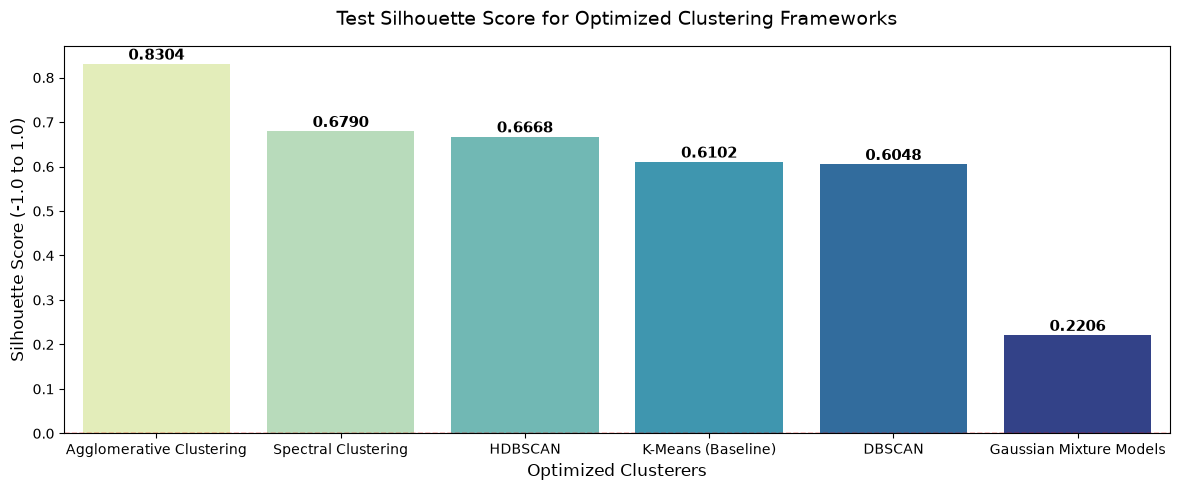

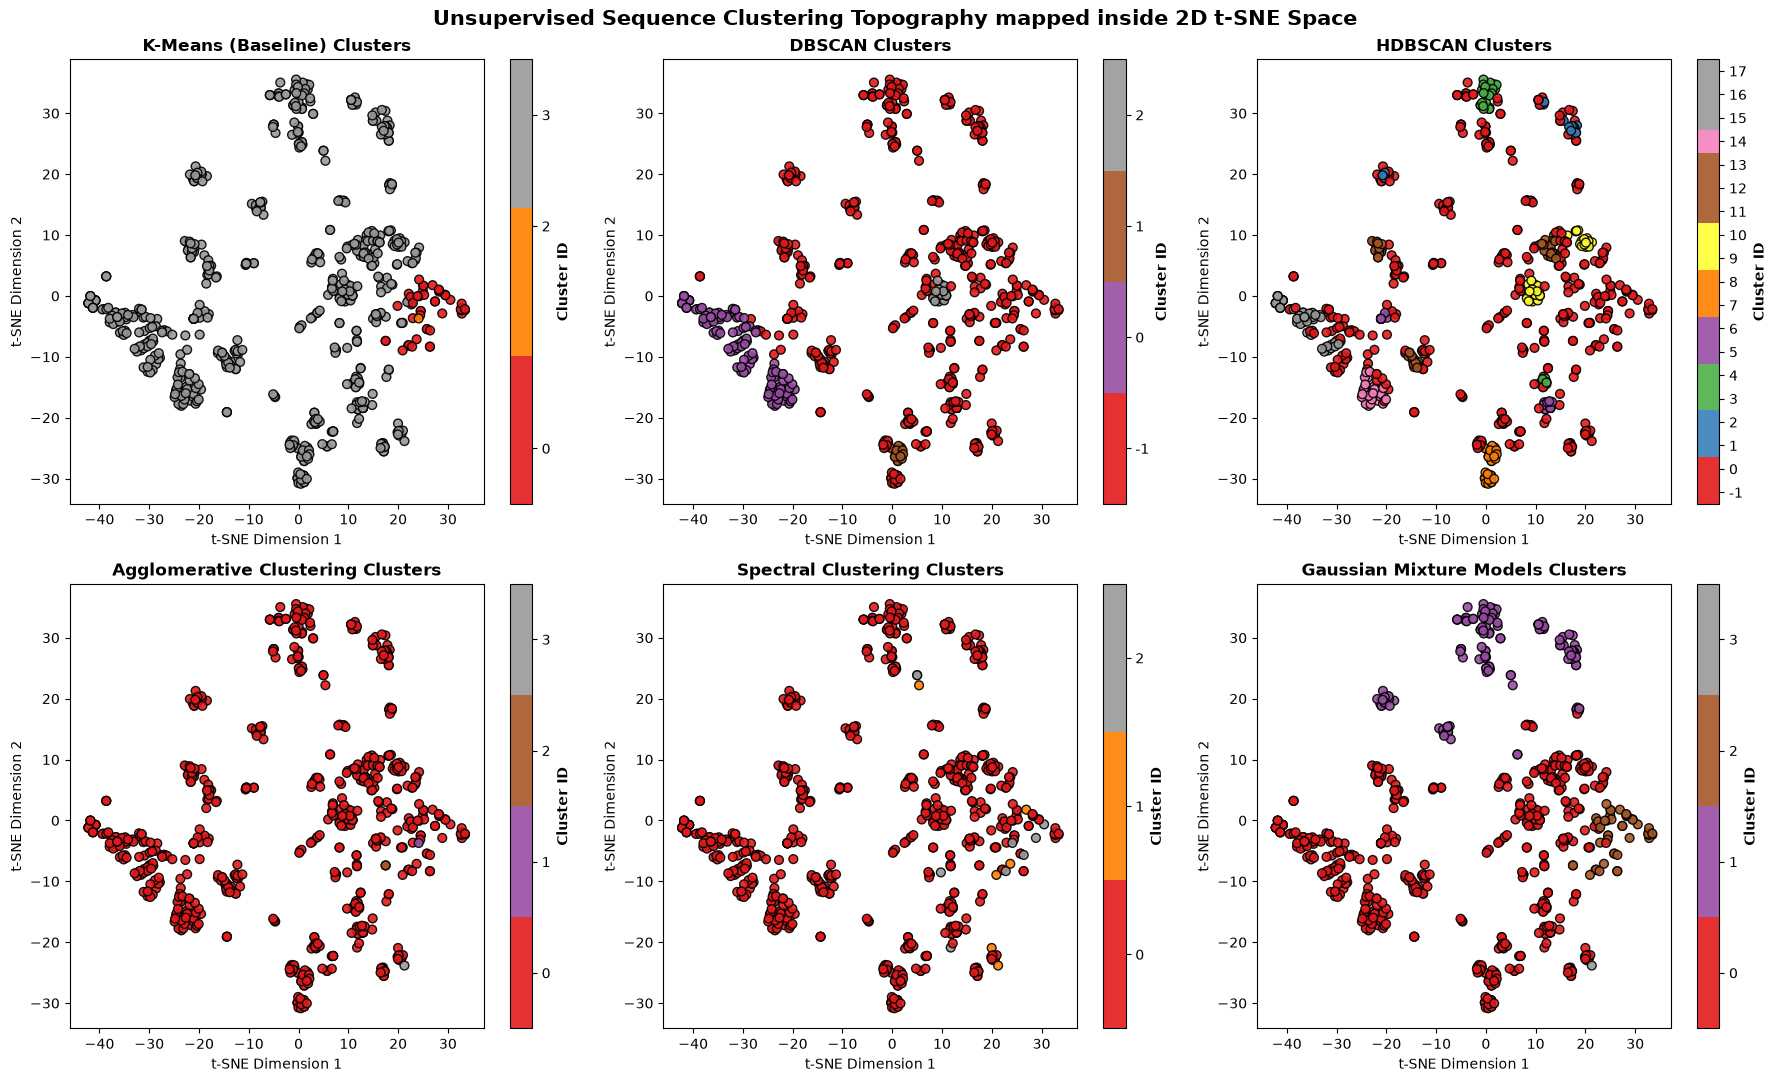

In [351]:
run_pipeline(is_all_sequences_dataset=True, should_apply_pca=False)

## With PCA

Original number of features: 77
Updated number of features: 58

Dataset split results:
	Train set shape:      X_train: (5392, 58), y_train: (5392,)
	Validation set shape: X_val: (600, 58), y_val: (600,)
	Test set shape:       X_test: (666, 58), y_test: (666,)

Applying PCA (target variance/components: 0.95)...
Shape before PCA: (5392, 58)
Shape after PCA: (5392, 31)
Total explained variance ratio: 0.9543

Optimal K-Means (Baseline) framework setup:
    init: k-means++
    n_init: 10
Validation Silhouette Score: 0.6380


Optimal DBSCAN framework setup:
    min_samples: 10
    algorithm: auto
    metric: manhattan
Validation Silhouette Score: 0.9418


Optimal HDBSCAN framework setup:
    min_cluster_size: 5
    min_samples: 5
    cluster_selection_epsilon: 0.0
    cluster_selection_method: leaf
    metric: manhattan
Validation Silhouette Score: 0.6348


Optimal Agglomerative Clustering framework setup:
    linkage: average
Validation Silhouette Score: 0.6872


Optimal Spectral Clustering

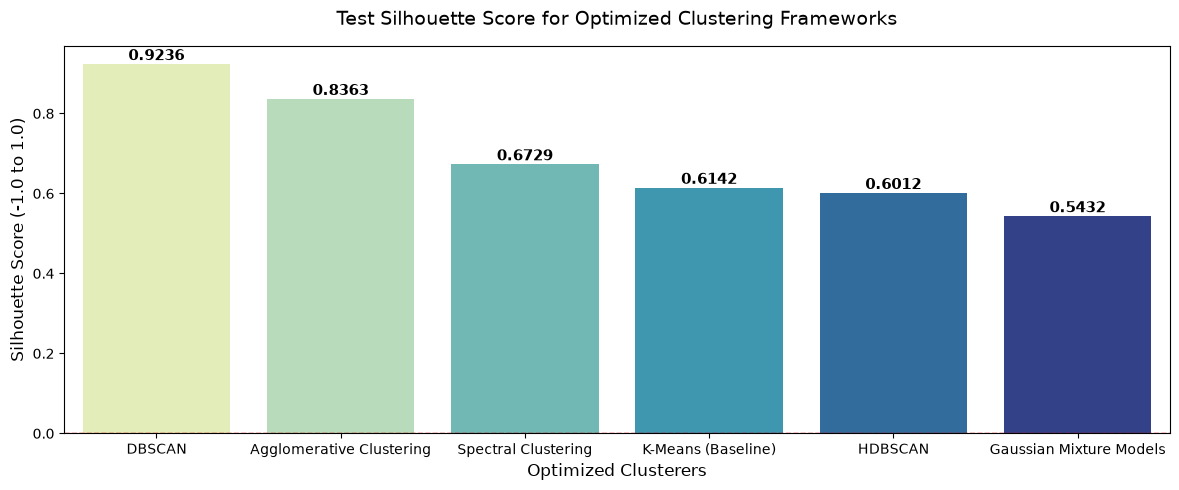

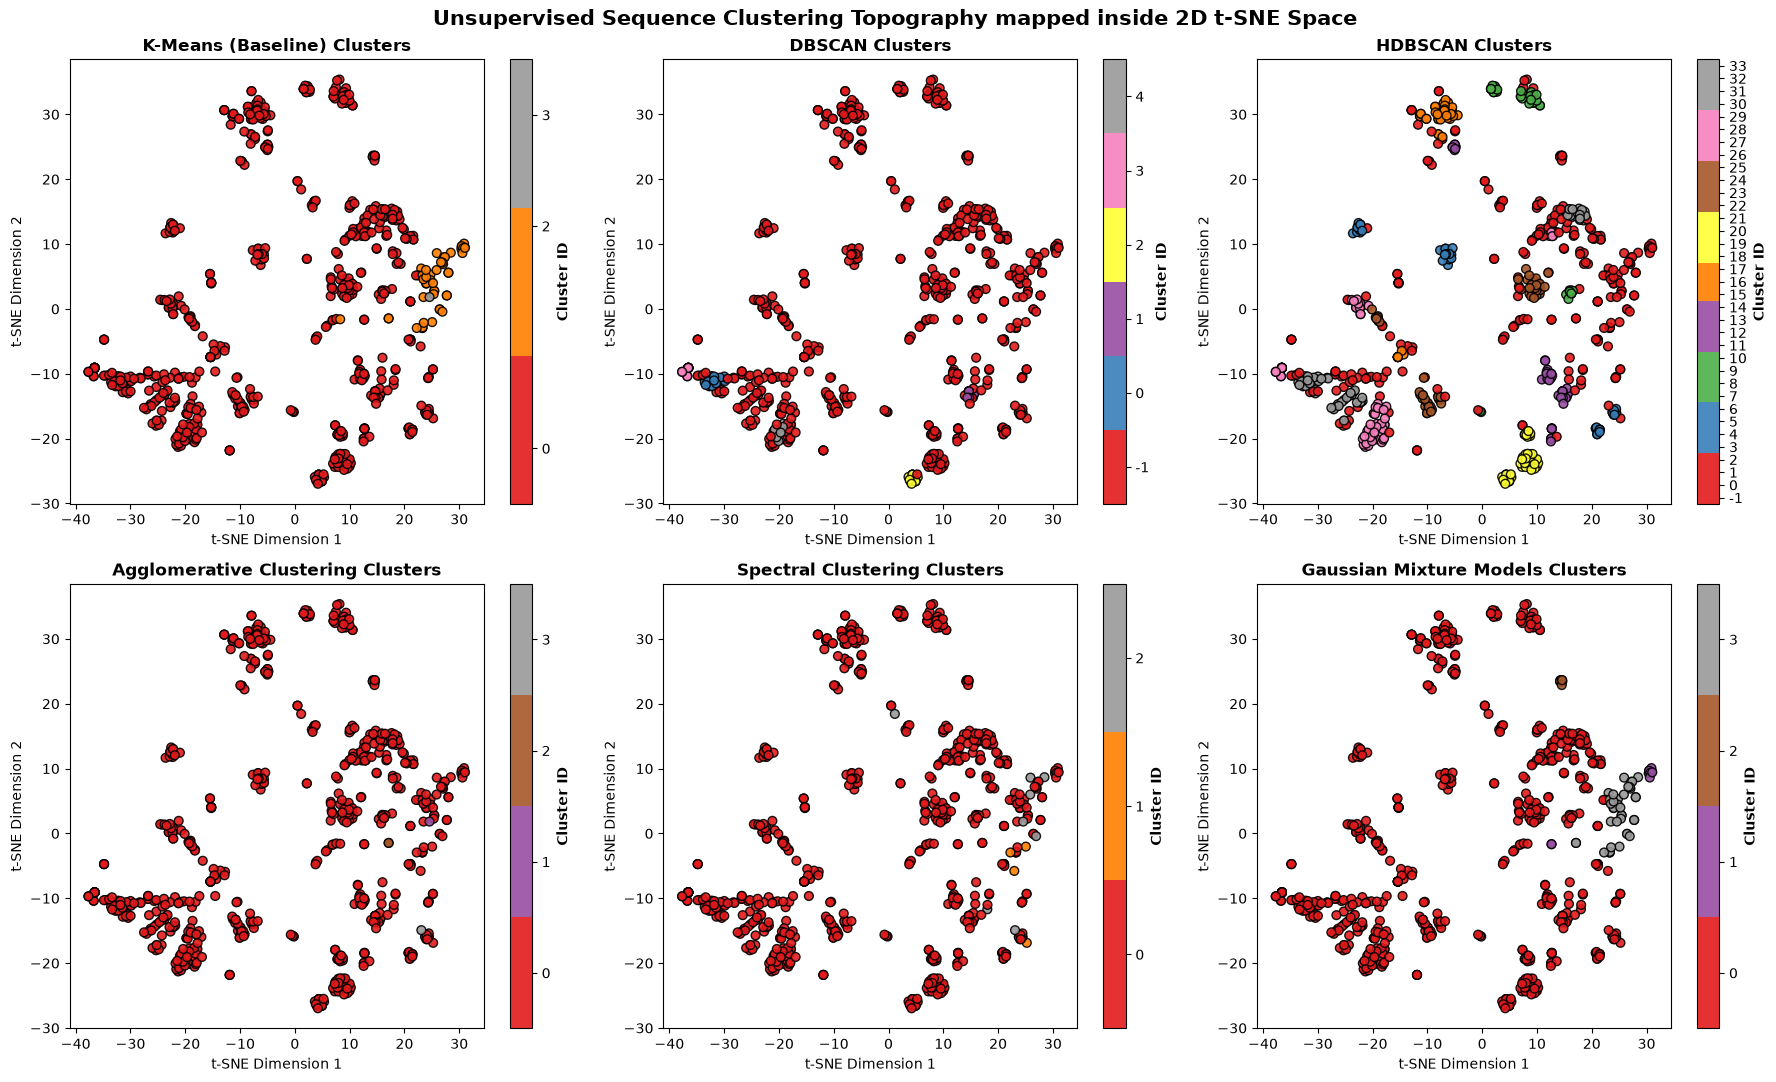

In [352]:
run_pipeline(is_all_sequences_dataset=True, should_apply_pca=True)

# Complete sequences dataset

Original number of features: 71
Updated number of features: 44

Dataset split results:
	Train set shape:      X_train: (337, 44), y_train: (337,)
	Validation set shape: X_val: (38, 44), y_val: (38,)
	Test set shape:       X_test: (42, 44), y_test: (42,)

Optimal K-Means (Baseline) framework setup:
    init: k-means++
    n_init: 10
Validation Silhouette Score: 0.0921


Optimal DBSCAN framework setup:
    min_samples: 3
    metric: cosine
Validation Silhouette Score: 0.2626


Optimal HDBSCAN framework setup:
    min_cluster_size: 4
    min_samples: 1
    cluster_selection_method: eom
    metric: euclidean
Validation Silhouette Score: 0.3223


Optimal Agglomerative Clustering framework setup:
    linkage: ward
Validation Silhouette Score: 0.4781


Optimal Spectral Clustering framework setup:
    affinity: rbf
    n_neighbors: 2
Validation Silhouette Score: 0.2973


Optimal Gaussian Mixture Models framework setup:
    covariance_type: spherical
Validation Silhouette Score: 0.1519



Final

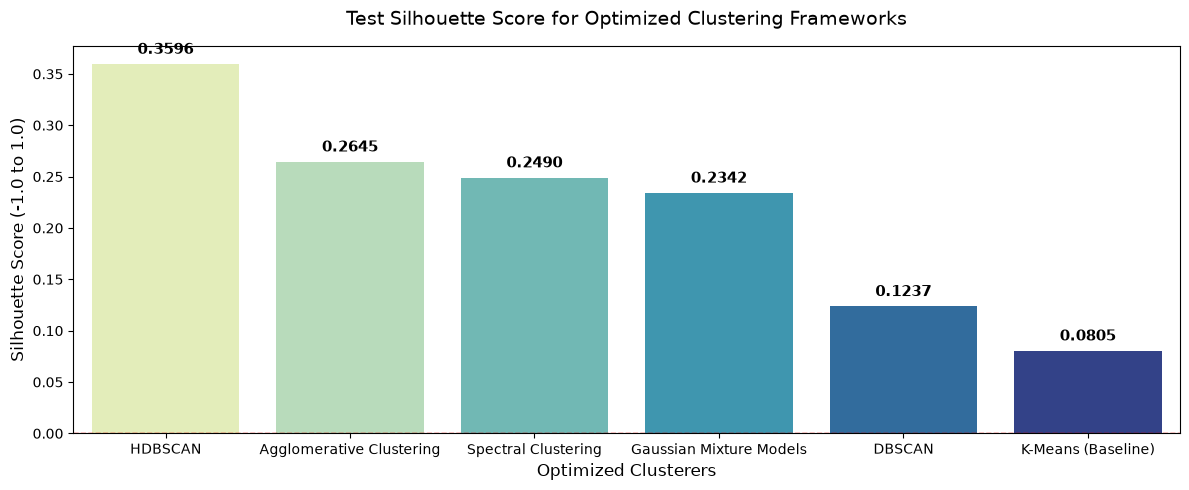

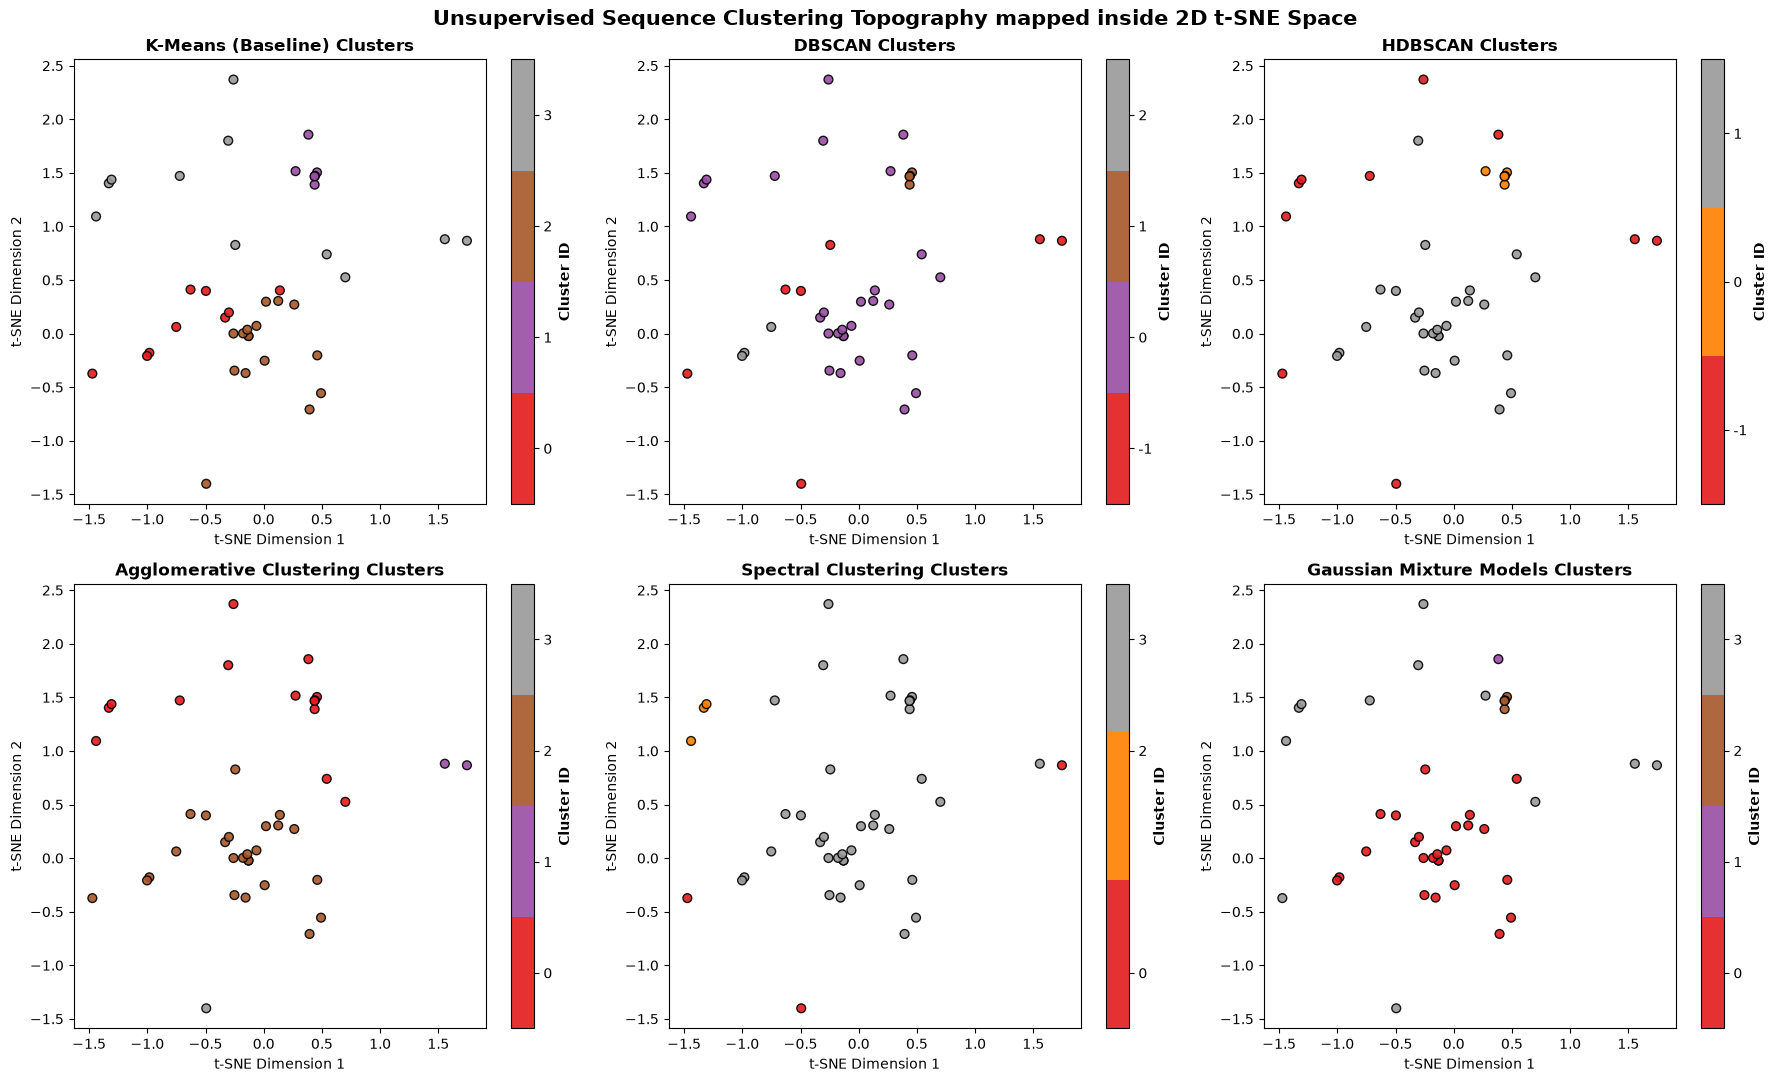

In [359]:
run_pipeline(is_all_sequences_dataset=False, should_apply_pca=False)

## With PCA

Original number of features: 71
Updated number of features: 44

Dataset split results:
	Train set shape:      X_train: (337, 44), y_train: (337,)
	Validation set shape: X_val: (38, 44), y_val: (38,)
	Test set shape:       X_test: (42, 44), y_test: (42,)

Applying PCA (target variance/components: 4)...
Shape before PCA: (337, 44)
Shape after PCA: (337, 4)
Total explained variance ratio: 0.3071

Optimal K-Means (Baseline) framework setup:
    init: k-means++
    n_init: 5
Validation Silhouette Score: 0.3987


Optimal DBSCAN framework setup:
    min_samples: 2
    metric: euclidean
Validation Silhouette Score: 0.1541


Optimal HDBSCAN framework setup:
    min_cluster_size: 4
    min_samples: 2
    cluster_selection_method: eom
    metric: manhattan
Validation Silhouette Score: 0.5751


Optimal Agglomerative Clustering framework setup:
    linkage: average
Validation Silhouette Score: 0.4891


Optimal Spectral Clustering framework setup:
    affinity: rbf
    n_neighbors: 2
Validation Silh

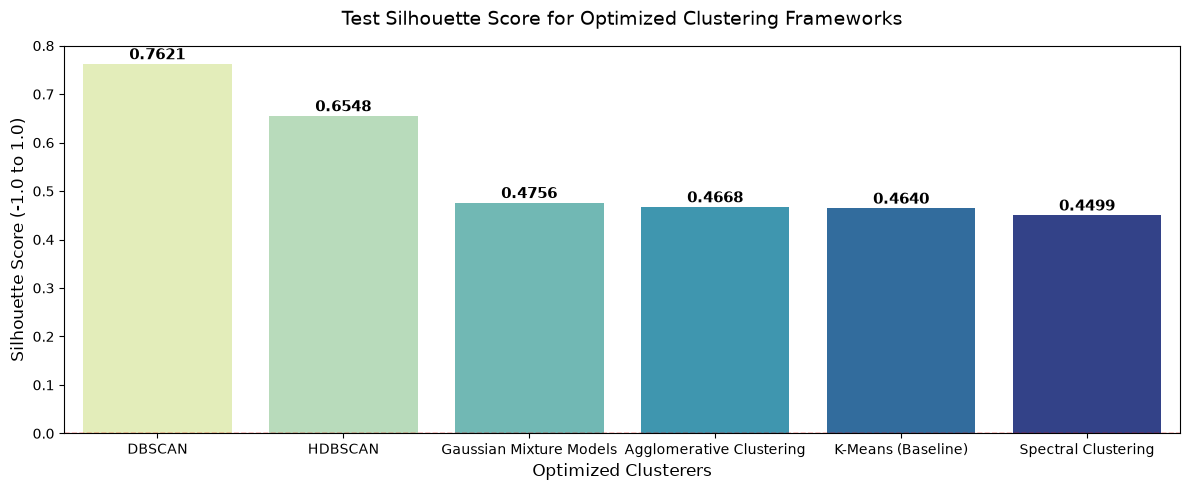

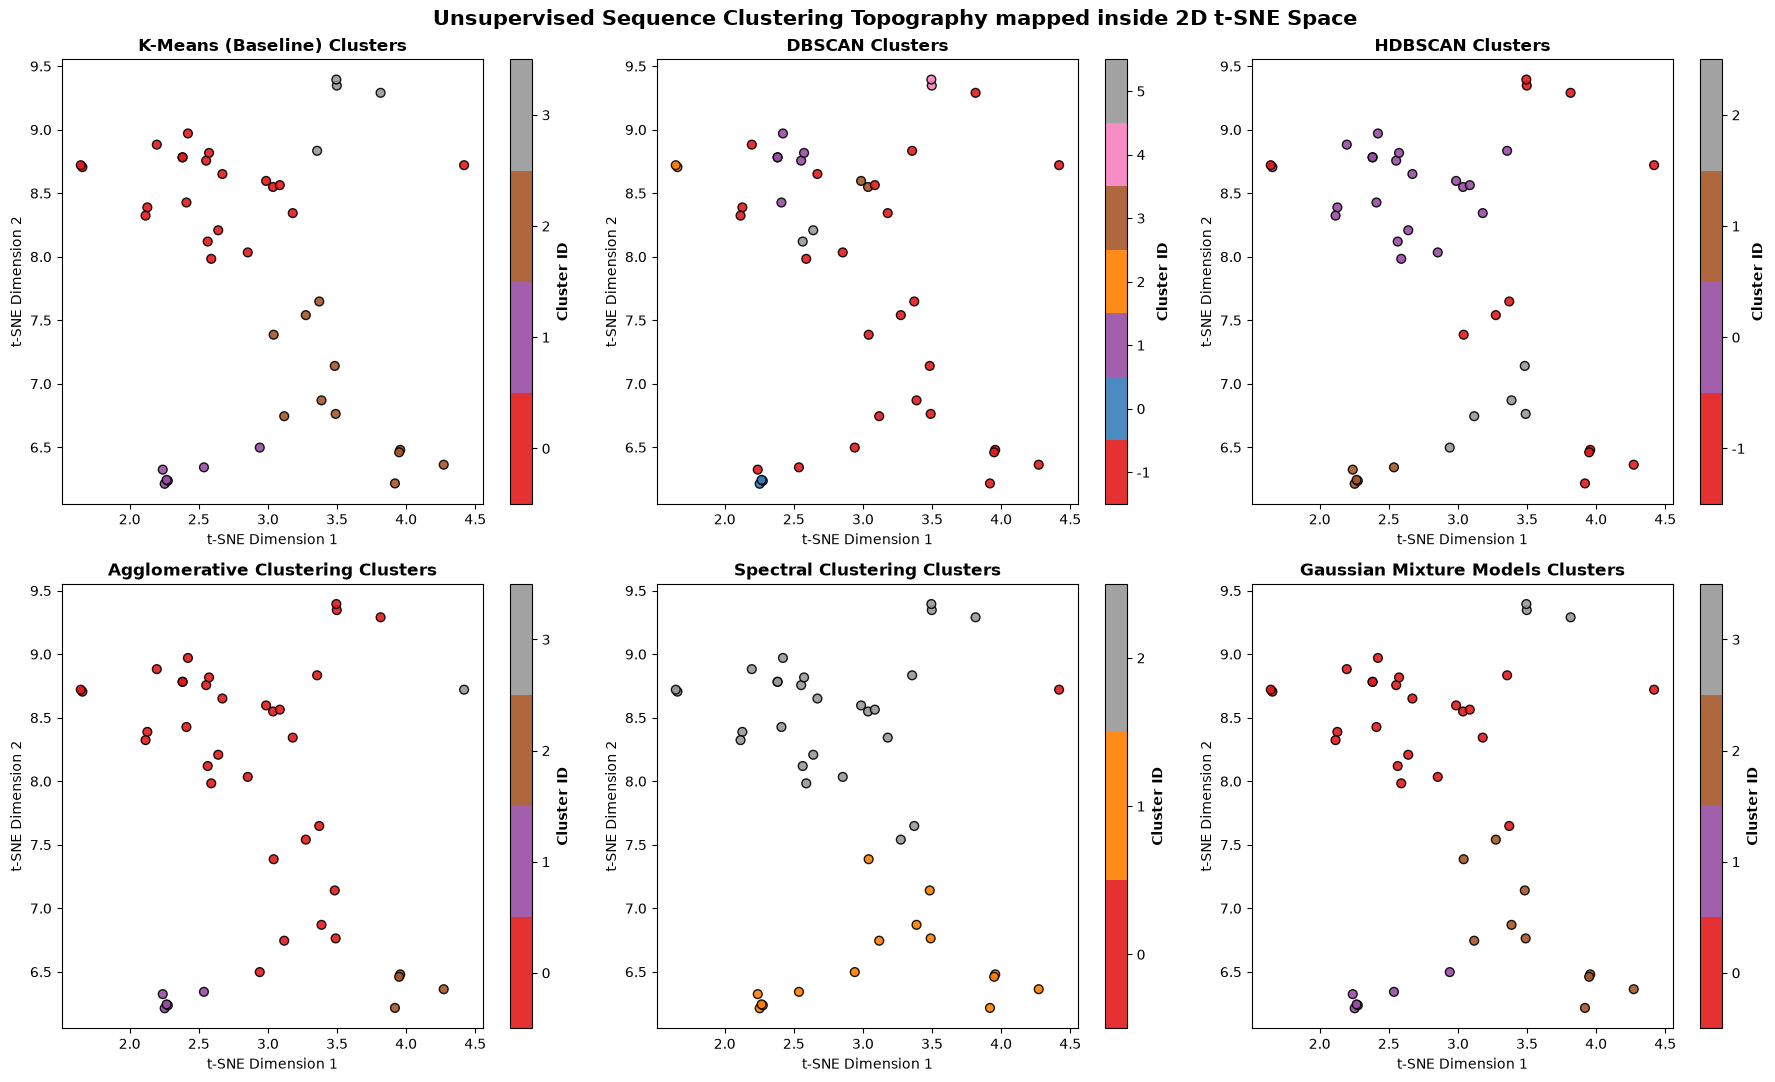

In [360]:
run_pipeline(is_all_sequences_dataset=False, should_apply_pca=True)